In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [3]:
wid = 80
oversample = 4

nwavels = 20
npoly=8

n_modes = 45
n_zernikes = 50

resolved_wid = 1

optics = NICMOSCoronagraph(512, wid, oversample, n_modes=n_modes, n_zernikes=n_zernikes, turboklip="../data/turboklip.npz")

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))


ddir = '../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/'
# ddir = '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/repaired/'

flatdir = '../data/NICMOS-LAPL-DD2/LAPL_HOLEFLATS_DD2/'

vects = np.load("../data/iterative_spectrum_basis_F160W.npy")[:,:npoly]
assert vects.shape == (nwavels, npoly)
spectrum_basis = vects/np.sqrt(np.mean(vects**2, axis=0))



exposures_single = [
    exposure_from_file(ddir + 'n8zu85ncq_m_clc_calf.fits', SinglePointFit(spectrum_basis, "F160W"), crop=wid, extra_bad=None, flatcorr=flatdir),
    # exposure_from_file(ddir + 'n8zu85ndq_m_clc_calf.fits', SinglePointFit(spectrum_basis, "F160W"), crop=wid),
]


ADCZERO                    0.0 / analog-digital conversion zero level (DN)       [astropy.io.fits.card]


31.95922 5.4
Version 4.1.1
56.8405


In [4]:
params = {
    "spectrum": {},
    "primary_klip": {},
    "primary_low": {},
    "primary_tilt": {},
    "cold_mask_tilt": {},
    "bias": {},
}


for idx, exp in enumerate(exposures_single):
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels)*5)

    params["primary_tilt"][exp.fit.get_key(exp, "primary_tilt")] = np.array([-0.75, -0.05])*0.075
    params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([
        # (np.array(exp.hdr["TARSIAFY"],dtype=float) - (256-44))-0.5,
        (np.array(exp.hdr["TARSIAFX"],dtype=float) - (256-181))+0.5, 
        (np.array(exp.hdr["TARSIAFY"],dtype=float) - (256-44))-0.5,
    ])*0.075

    params["primary_klip"][exp.fit.get_key(exp, "primary_klip")] = np.zeros(7)
    params["primary_low"][exp.fit.get_key(exp, "primary_low")] = np.zeros((n_zernikes))

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.

params = params | np.load("../data/optical_params.npy", allow_pickle=True)[()]
    

model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))

params = ModelParams(params)

(45, 45) 45
(45, 45) 45
19.136526345105654


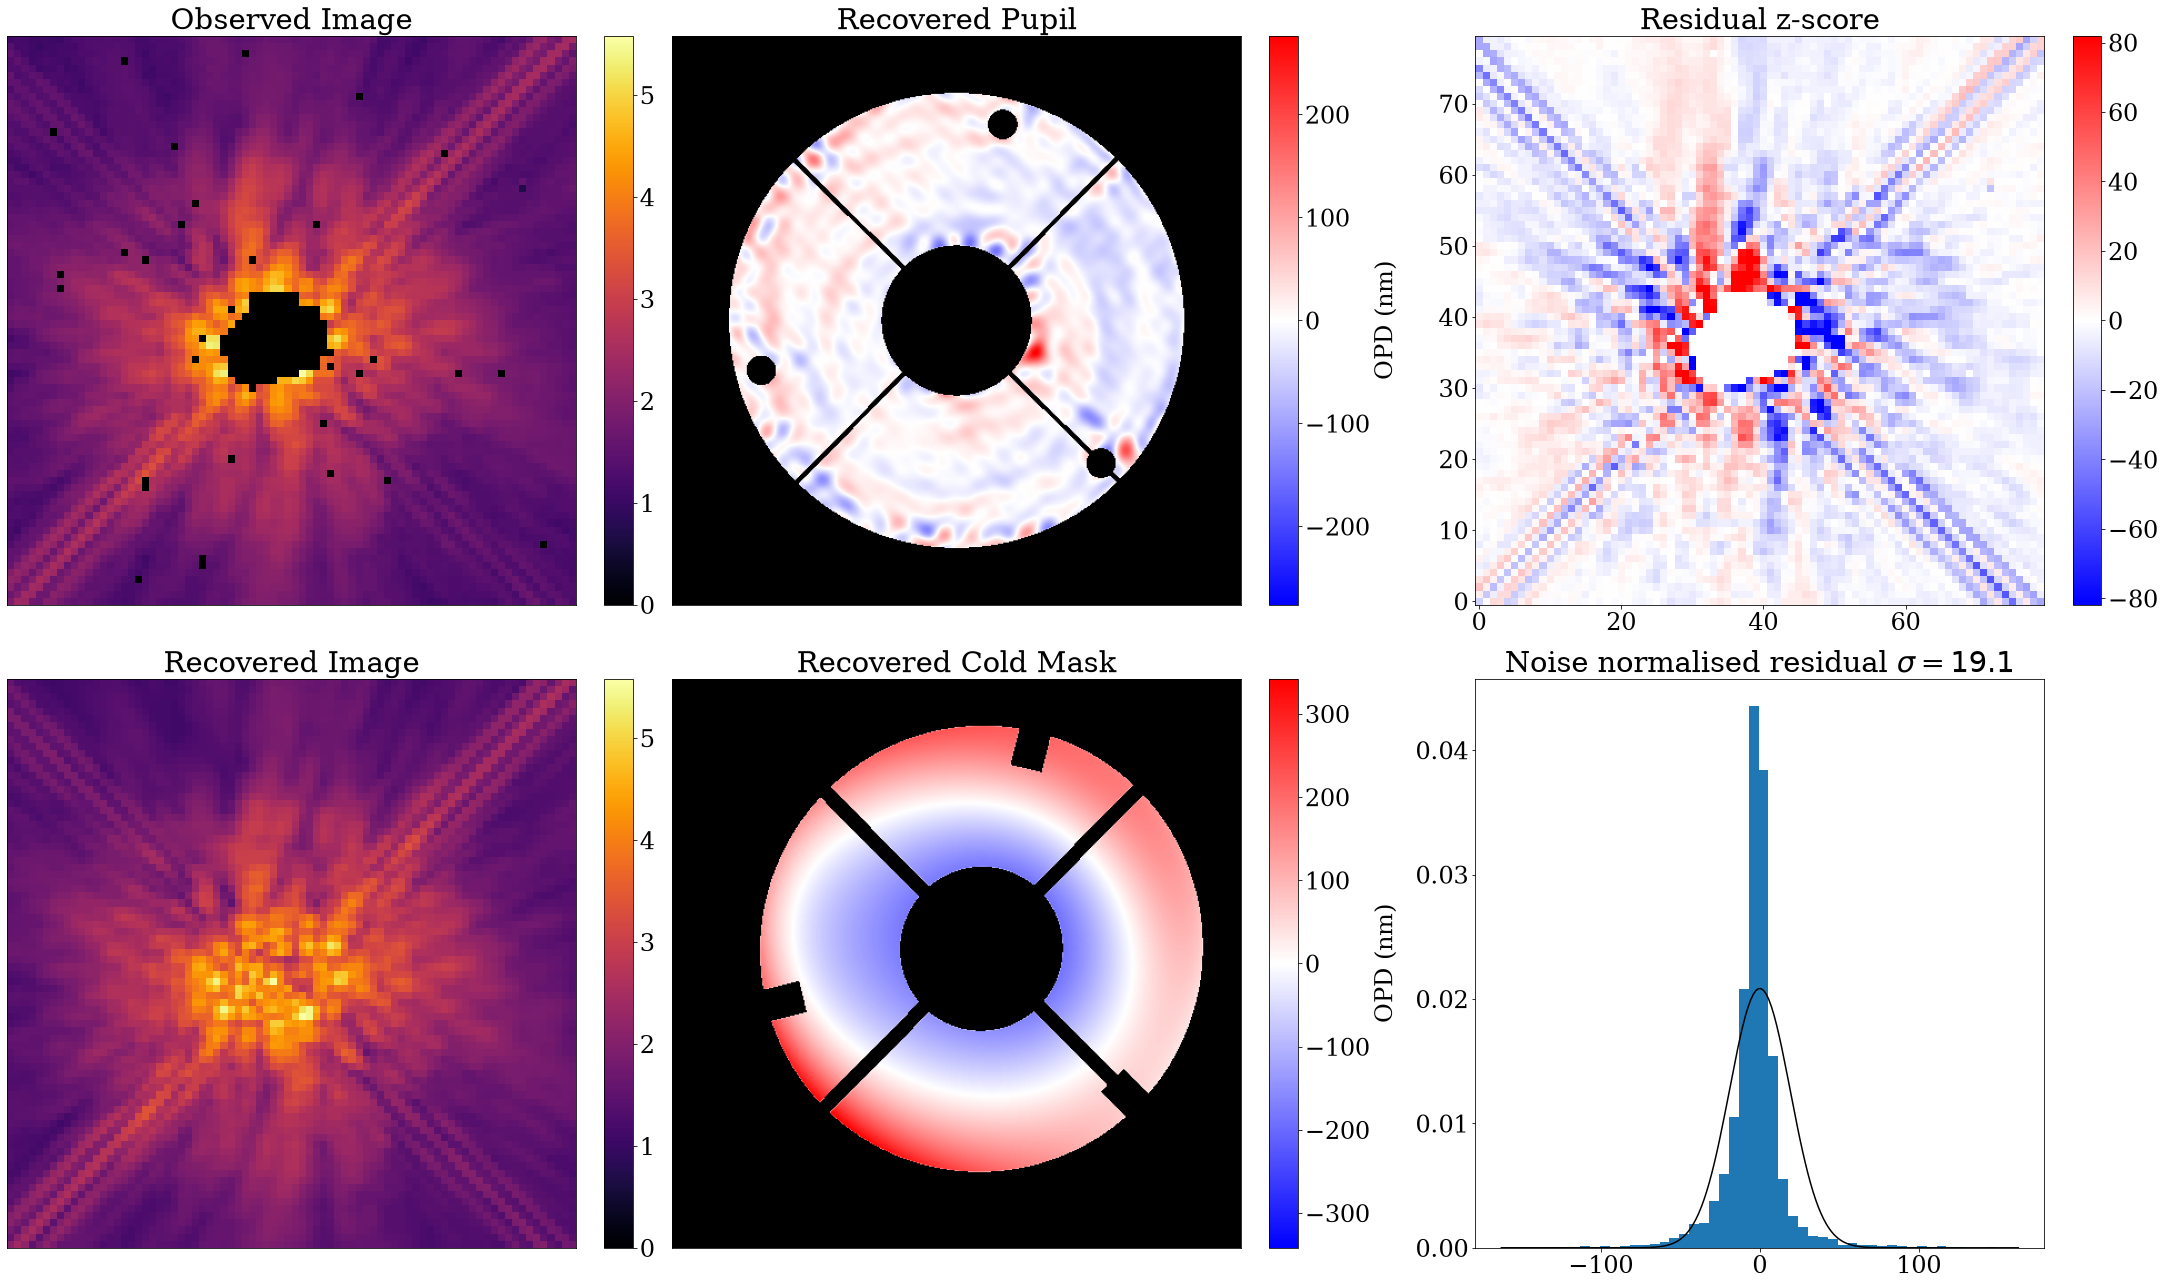

In [5]:
plot_comparison(model_single, params, exposures_single, percentile=99, wf_size=512, klip=True)

In [6]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)

def adam(lr, delay):
    return optax.adam(zdx.optimisation.delay(lr, delay))


g = 5e-2



things_start = {
    "spectrum": sgd(g*3, 30.),
    "primary_tilt": sgd(g*1, 15.),
    "cold_mask_tilt": sgd(g*0.1, 0),

    "bias": sgd(g*3, 40),
    "cold_mask_shift": sgd(g*0.1, 50),
    # "cold_mask_rot": sgd(g*0.2, 85),
    # "primary_rot": sgd(g*1, 85),

    "primary_low": sgd(g*2, 70),
    "primary_klip": sgd(g*0.5, 100),

    # "cold_mask_scale": sgd(g*5, 100),
    # "cold_mask_shear": sgd(g*10, 100),

    # # "primary_scale": sgd(g*5, 100),
    # "primary_shear": sgd(g*10, 100),

    # "occulter_radius": sgd(g*1., 120),
    # # "occulter_coeffs": sgd(g*1, 120),
    # # # "fnumber": sgd(g*2., 150),
}

In [7]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [ ]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things_start, 200, nbatches=10)

(45, 45) 45


  0%|          | 0/500 [00:00<?, ?it/s]

(45, 45) 45


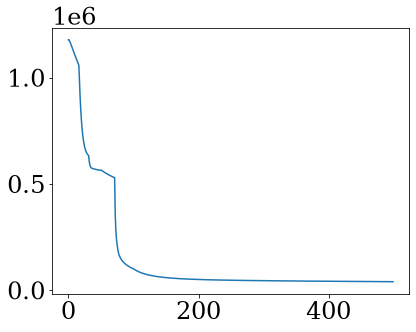

In [9]:
plt.plot(losses[:])

7
(45, 45) 45
(45, 45) 45
3.5941701289149477


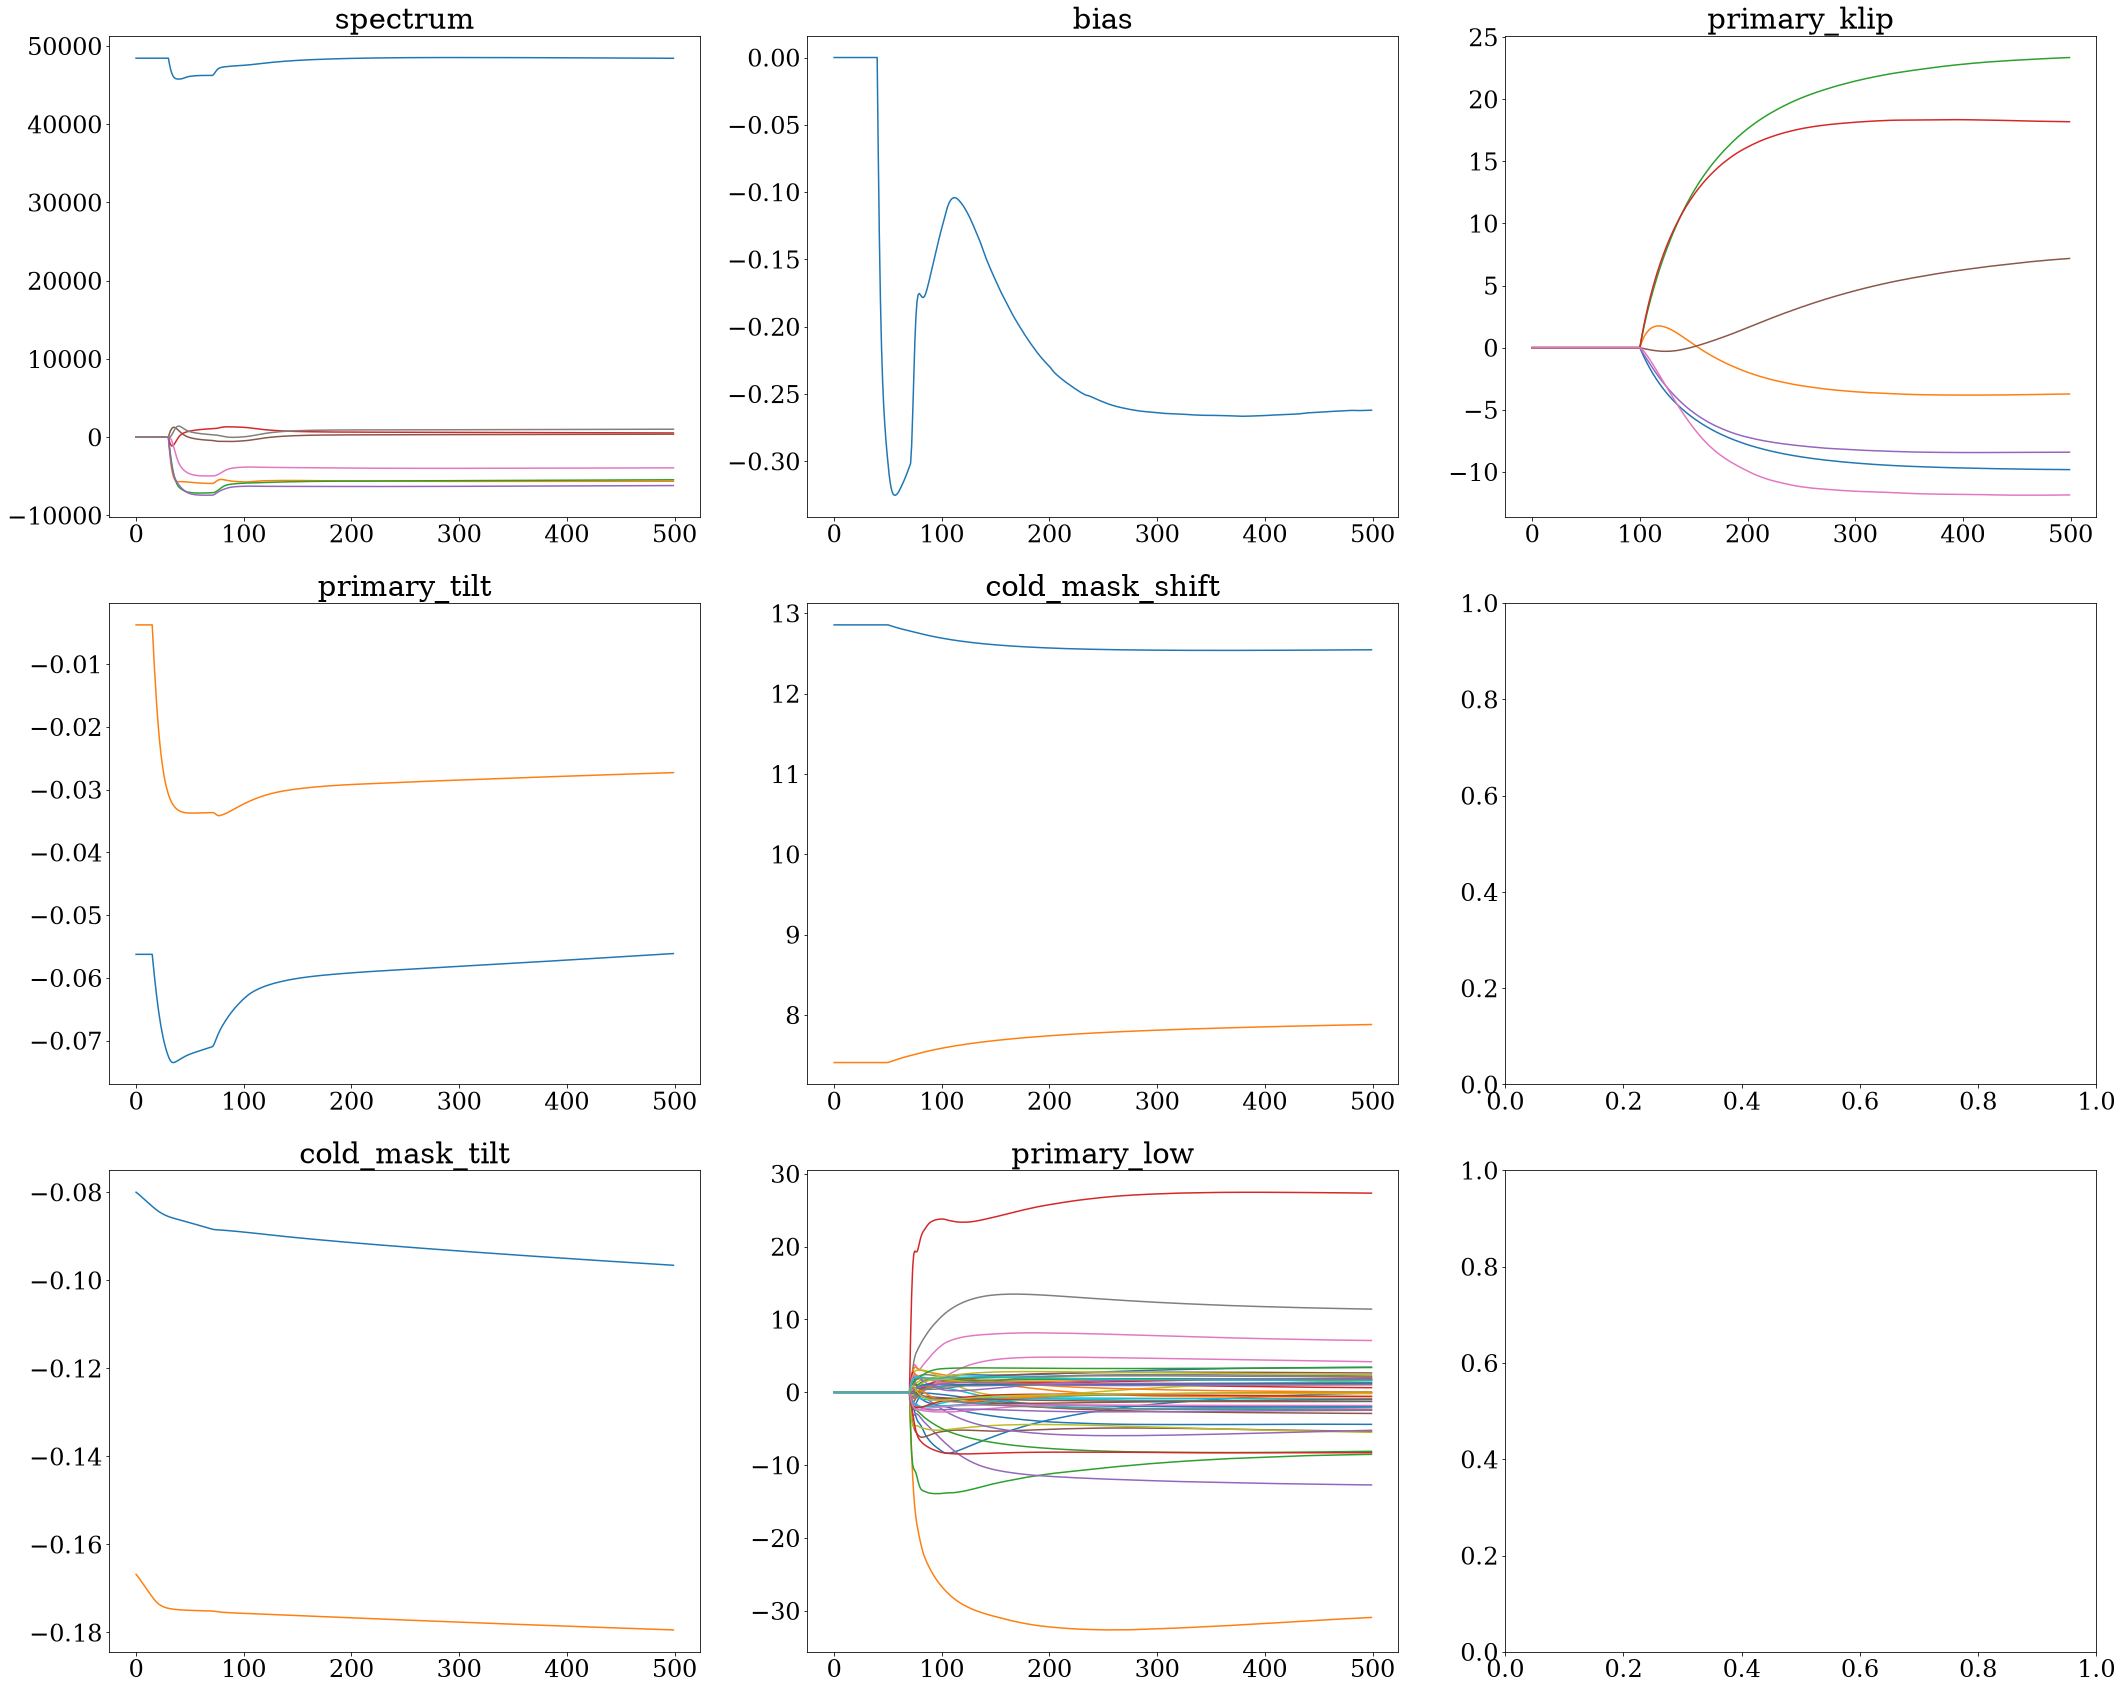

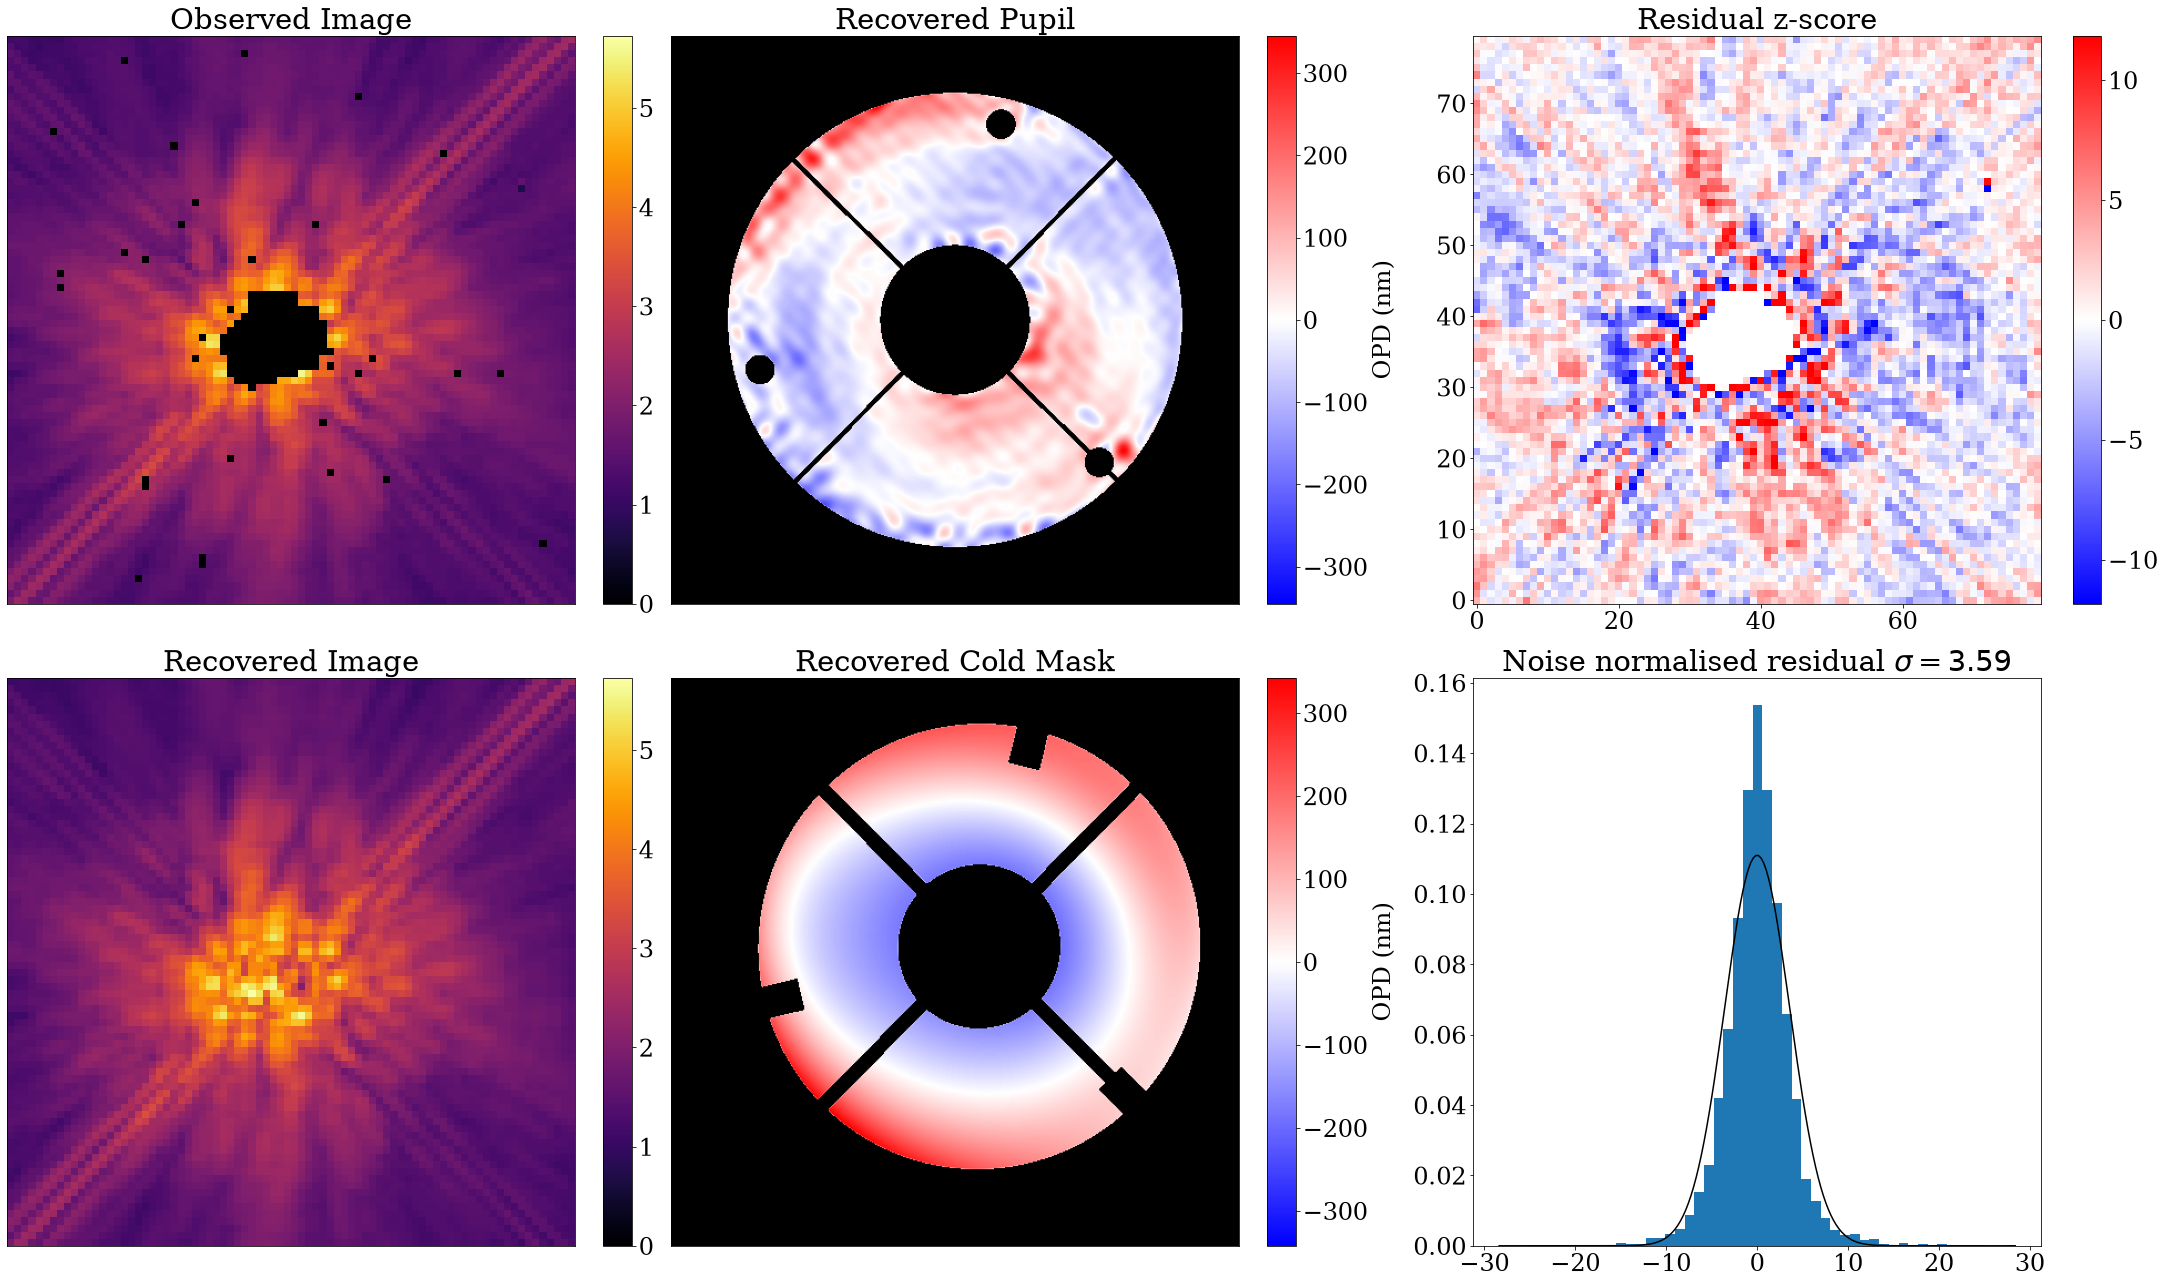

In [10]:
plot_params(params_history, list(things_start.keys()), xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, percentile=99, quadrature=False, wf_size=512, klip=True)